Firstly, we can connect to the CPSC API and extract the JSON which is then converted to a dataframe.

In [47]:
import requests
import pandas as pd

url = "https://www.saferproducts.gov/RestWebServices/Recall"

params = {
    "format": "json"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=30
)

print(response.status_code)
print(response.url)

response.raise_for_status()

data = response.json()

df = pd.json_normalize(data)

print(df.head())

200
https://www.saferproducts.gov/RestWebServices/Recall?format=json
   RecallID RecallNumber           RecallDate  \
0     10949        26733  2026-09-03T00:00:00   
1     10948        26731  2026-09-03T00:00:00   
2     10944        26735  2026-09-03T00:00:00   
3     10940        26741  2026-09-03T00:00:00   
4     10947        26734  2026-09-03T00:00:00   

                                         Description  \
0  This recall involves Loyoda-branded adult port...   
1  This recall involves the Cambridge Audio Yoyo ...   
2  This recall involves height-adjustable ergonom...   
3  This recall only includes Mistolin and Lestoil...   
4  This recall involves certain Amana brand Throu...   

                                                 URL  \
0  https://cpsc.gov/Recalls/2026/Adult-Portable-B...   
1  https://cpsc.gov/Recalls/2026/Audio-Partnershi...   
2  https://cpsc.gov/Recalls/2026/Branch-Recalls-E...   
3  https://cpsc.gov/Recalls/2026/Clorox-Puerto-Ri...   
4  https://cpsc.gov

df.shape allows us to examine the number of rows and columns in the dataset

In [48]:
df.shape

(9990, 22)

df.info allows us to examine if there are any null values in the dataset-- there appear to be many null values in the column named "consumer contact."

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   RecallID               9990 non-null   int64 
 1   RecallNumber           9990 non-null   object
 2   RecallDate             9990 non-null   object
 3   Description            9989 non-null   object
 4   URL                    9990 non-null   object
 5   Title                  9990 non-null   object
 6   ConsumerContact        8299 non-null   object
 7   LastPublishDate        9990 non-null   object
 8   Products               9990 non-null   object
 9   Inconjunctions         9990 non-null   object
 10  Images                 9990 non-null   object
 11  Injuries               9990 non-null   object
 12  Manufacturers          9990 non-null   object
 13  Retailers              9990 non-null   object
 14  Importers              9990 non-null   object
 15  Distributors         

In [50]:
df['RecallYear'] = df['RecallDate'].str[0:4]
df['RecallYear']

,RecallYear
0,2026
1,2026
2,2026
3,2026
4,2026
...,...
9985,1973
9986,1973
9987,1973
9988,1973


<Axes: xlabel='RecallYear'>

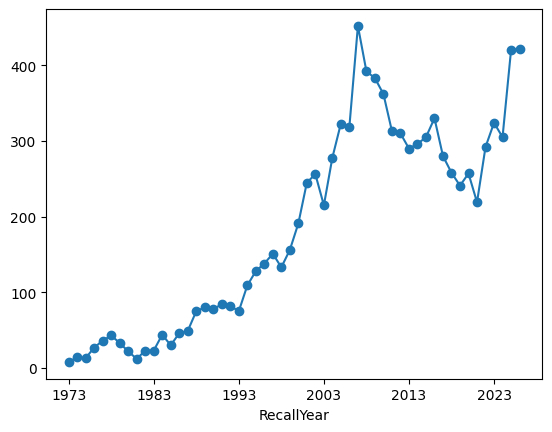

In [51]:
counts.plot(kind="line", marker="o")

We examine the injuries field to understand how injury information is represented. Because injuries are stored as free-text descriptions, additional text processing would be required to quantify specific injury types.

In [52]:
df["Injuries"].value_counts().head(50)

,count
Injuries,
[],1670
[{'Name': 'None reported'}],1444
[{'Name': 'None reported.'}],1205
[{'Name': 'No incidents or injuries have been reported.'}],91
[{'Name': 'None.'}],61
[{'Name': 'None'}],44
[{'Name': 'No injuries have been reported.'}],36
[{'Name': 'No injuries or incidents have been reported.'}],21
[{'Name': 'None Reported'}],16


Here we can examine the different hazards associated with each product. It appears choking and fire related hazards are the most common.

In [53]:
df["Hazards"].value_counts().head(20)

,count
Hazards,
"[{'Name': 'Choking', 'HazardType': '', 'HazardTypeID': ''}]",362
"[{'Name': 'Fire & Fire-Related Burn', 'HazardType': '', 'HazardTypeID': ''}]",288
[],169
"[{'Name': 'Electrocution/Electric Shock', 'HazardType': '', 'HazardTypeID': ''}]",162
"[{'Name': 'Laceration', 'HazardType': '', 'HazardTypeID': ''}]",157
"[{'Name': 'Fall', 'HazardType': '', 'HazardTypeID': ''}]",98
"[{'Name': 'Poisoning', 'HazardType': '', 'HazardTypeID': ''}]",56
"[{'Name': 'Entrapment', 'HazardType': '', 'HazardTypeID': ''}]",51
"[{'Name': 'Lead', 'HazardType': '', 'HazardTypeID': ''}]",42


To examine the different types of products in the dataset, we need to parse the Products column and extract the "Type" value from each dictionary in the lists.

In [54]:
df["Products"].value_counts()

,count
Products,
"[{'Name': 'Flying Copter flying helicopter toys', 'Description': '', 'Model': '', 'Type': 'Toy Helicopters', 'CategoryID': '2195', 'NumberOfUnits': ''}]",4
"[{'Name': 'Portable bed handles', 'Description': '', 'Model': '', 'Type': 'Bed Rails', 'CategoryID': '67745', 'NumberOfUnits': 'About 113,000'}]",3
"[{'Name': 'Siren Whistle toys', 'Description': '', 'Model': '', 'Type': 'Toy Whistles', 'CategoryID': '2209', 'NumberOfUnits': ''}]",3
"[{'Name': 'Rainbow Bell baby rattles', 'Description': '', 'Model': '', 'Type': 'Rattles', 'CategoryID': '2093', 'NumberOfUnits': ''}]",2
"[{'Name': 'Siebe actuators', 'Description': '', 'Model': '', 'Type': 'Dampers', 'CategoryID': '1906', 'NumberOfUnits': 'Up to 560,000'}]",2
...,...
"[{'Name': 'Cookware', 'Description': '', 'Model': '', 'Type': 'Metal Cookware (Nonelectric)', 'CategoryID': '68154', 'NumberOfUnits': 'About 41,000'}]",1
"[{'Name': 'green sprouts® glass food cubes', 'Description': '', 'Model': '', 'Type': 'Food Preservers', 'CategoryID': '68146', 'NumberOfUnits': 'About 68,000 (in addition, about 300 sold in Canada)'}]",1
"[{'Name': '100-watt bendable solar panels', 'Description': '', 'Model': '', 'Type': 'Electrical Systems', 'CategoryID': '67876', 'NumberOfUnits': 'About 1,500 (in addition, about 20 solar panels were sold in Canada)'}]",1


In [55]:
df["Product_Type"] = df["Products"].str[0].str["Type"]
df["Product_Type"].value_counts().head(20)

,count
Product_Type,
,3341
Clothing (Children),253
Bicycles & Accessories,182
Candles & Candle Holders,142
Toy Animals Stuffed/Not Stuffed,131
Adapter/Power Supply/Charger/Battery,131
Toy Miscellaneous,118
Bicycles and Bicycle Accessories,107
Cribs,106


After examing the "Clothing (Children)" Product Type, we find that the hazard most associated with these items is choking due to drawstring design.

In [56]:
df_clothing = df[df["Product_Type"] == "Clothing (Children)"]
df_clothing.head(5)

,RecallID,RecallNumber,RecallDate,Description,URL,Title,ConsumerContact,LastPublishDate,Products,Inconjunctions,...,Importers,Distributors,SoldAtLabel,ManufacturerCountries,ProductUPCs,Hazards,Remedies,RemedyOptions,RecallYear,Product_Type
3334,6627,16076,2016-01-19T00:00:00,This recall involves two styles of infant one-...,https://www.cpsc.gov/Recalls/2016/Walt-Disney-...,Walt Disney Parks and Resorts Recalls Infant B...,Walt Disney Parks and Resorts toll-free at 844...,2016-01-19T00:00:00,[{'Name': 'Darth Vader and Disneyland 60th inf...,[],...,"[{'Name': 'Walt Disney Parks and Resorts, of L...",[],None,[{'Country': 'Guatemala'}],[],[{'Name': 'The snaps on the bodysuits can deta...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Refund'}],2016,Clothing (Children)
3484,6470,15208,2015-08-06T00:00:00,This recall involves Precious Cargo® infant on...,https://www.cpsc.gov/Recalls/2015/Precious-Car...,Precious Cargo Recalls Infant One-Piece Garmen...,Precious Cargo toll free at (888) 770-7018 fro...,2015-08-06T00:00:00,[{'Name': 'Precious Cargo infant one-piece gar...,[],...,"[{'Name': 'SanMar Corp., of Issaquah, Wash.', ...",[],None,[{'Country': 'Vietnam'}],[],[{'Name': 'The snaps on the one-piece garments...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Refund'}],2015,Clothing (Children)
3824,1683,14180,2014-05-15T00:00:00,This recall involves girls' leggings sold in t...,https://www.cpsc.gov/Recalls/2014/HM-Recalls-G...,H&M Recalls Girls’ Leggings Due to Choking Hazard,H&M Customer Service toll-free at (855) 466-74...,2015-01-09T00:00:00,"[{'Name': 'Girls' Leggings', 'Description': ''...",[],...,[],"[{'Name': 'H&M Hennes & Mauritz L.P., of North...",None,"[{'Country': 'Bangladesh'}, {'Country': 'China...",[],[{'Name': 'A metal part on the belt can detach...,[{'Name': 'Consumers should stop using the bel...,[{'Option': 'Refund'}],2014,Clothing (Children)
3838,1811,14732,2014-05-01T00:00:00,This recall involves all styles of J. Crew Hol...,https://www.cpsc.gov/Recalls/2014/J-Crew-Recal...,J. Crew Recalls Baby Coveralls Due to Choking ...,"J. Crew Group, Inc. at (800) 261-7422 anytime ...",2014-05-23T00:00:00,"[{'Name': 'Baby Coveralls', 'Description': '',...",[],...,"[{'Name': 'J. Crew Group Inc., of New York, N....",[],None,[{'Country': 'China'}],[],"[{'Name': 'Snaps on the coveralls can detach, ...",[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Refund'}],2014,Clothing (Children)
3941,1789,14709,2014-01-15T00:00:00,The infant home kit consists of a white jersey...,https://www.cpsc.gov/Recalls/2014/Under-Armour...,Under Armour Recalls Infant Sports Jersey Kits...,Under Armour toll-free at (888) 823-0343 from ...,2014-05-23T00:00:00,[{'Name': 'Tottenham Hotspur Infant Home Kits'...,[],...,"[{'Name': 'Under Armour, Inc., of Baltimore, M...",[],None,[{'Country': 'Philippines'}],[],[{'Name': 'The shoulder snaps on the jersey ca...,[{'Name': 'Consumers should immediately take t...,[{'Option': 'Refund'}],2014,Clothing (Children)


In [57]:
df_clothing["Hazard Name"] = df_clothing["Hazards"].str[0].str["Name"]
df_clothing["Hazard Name"].value_counts().head(10)

/tmp/ipykernel_1063/3888408735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clothing["Hazard Name"] = df_clothing["Hazards"].str[0].str["Name"]


,count
Hazard Name,
Choking,19
"The garments have a drawstring through the hood, posing a strangulation hazard to children.",10
"The garments have a drawstring through the hood, which can pose a strangulation hazard to children.",8
The sweatshirts have a drawstring through the hood which can pose a strangulation hazard to children.,7
"The jackets have a drawstring through the hood, which can pose a strangulation hazard to children.",6
Fire & Fire-Related Burn,6
"The sweatshirts have a drawstring through the hood, which can pose a strangulation hazard to children.",4
"Waist drawstring on jacket is longer than 3 inches when the waist is expanded to its fullest width, and there are toggles and knots at the end of the un-tacked drawstring. This can cause the drawstring to catch on protrusions (such as bus doors or handles), potentially causing injury or death if the person is dragged by the vehicle.",3
Lead,3


For Cribs, the most common hazard is entrapment

In [58]:
df_cribs = df[df["Product_Type"] == "Cribs"]
df_cribs.head(5)

,RecallID,RecallNumber,RecallDate,Description,URL,Title,ConsumerContact,LastPublishDate,Products,Inconjunctions,...,Importers,Distributors,SoldAtLabel,ManufacturerCountries,ProductUPCs,Hazards,Remedies,RemedyOptions,RecallYear,Product_Type
3425,6534,16002,2015-10-01T00:00:00,The recall includes DaVinci brand full-size cr...,https://www.cpsc.gov/Recalls/2016/Bexco-Expand...,Bexco Expands Recall of DaVinci Brand Cribs Du...,DaVinci toll-free at 888-673-6652 from 8:30 a....,2015-10-01T00:00:00,"[{'Name': 'DaVinci Cribs', 'Description': '', ...",[{'URL': 'http://healthycanadians.gc.ca/recall...,...,[],[],None,[{'Country': 'China'}],[],[{'Name': 'A metal bracket that connects the m...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Repair'}],2015,Cribs
3568,6383,15131,2015-05-08T00:00:00,This recall involves Baby's Dream full-size cr...,https://www.cpsc.gov/Recalls/2015/Babys-Dream-...,Baby's Dream Recalls Cribs and Furniture Due t...,Baby's Dream Furniture at (800) 835-2742 from ...,2015-05-08T00:00:00,"[{'Name': 'Cribs, furniture and accessories wi...",[],...,[],[],None,[{'Country': 'Chile'}],[],[{'Name': 'The vintage gray paint on the cribs...,[{'Name': 'Consumers should immediately contac...,[{'Option': 'Replace'}],2015,Cribs
3750,1750,14258,2014-08-19T00:00:00,This recall includes Franklin & Ben Mason styl...,https://www.cpsc.gov/Recalls/2014/Bexco-Recall...,Bexco Recalls Franklin & Ben Mason 4-in-1 Conv...,"Contact Franklin and Ben, a division of Bexco,...",2015-01-09T00:00:00,[{'Name': 'Franklin & Ben Mason 4-in-1 Convert...,[{'URL': 'https://healthycanadians.gc.ca/recal...,...,[],[],None,[{'Country': 'Taiwan'}],[],[{'Name': 'The crib front can separate from th...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Repair'}],2014,Cribs
3774,1731,14236,2014-07-22T00:00:00,The recall includes four models of Oeuf Sparro...,https://www.cpsc.gov/Recalls/2014/Oeuf-Recalls...,Oeuf Recalls to Repair Cribs Due to Entrapment...,Oeuf toll-free at (844) 653-8527 from 10 a.m. ...,2015-01-09T00:00:00,"[{'Name': 'Sparrow Cribs', 'Description': '', ...",[],...,"[{'Name': 'Oeuf LLC, of Brooklyn, N.Y.', 'Comp...",[],None,[{'Country': 'Latvia'}],[],[{'Name': 'The slats/spindles and top rail can...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Repair'}],2014,Cribs
3998,1545,14019,2013-11-13T00:00:00,This recall involves the Lullaby Cradle Glider...,https://www.cpsc.gov/Recalls/2014/Dream-On-Me-...,Dream On Me Recalls Cradle Gliders Due to Infa...,Dream On Me toll-free at (877) 201-4317 from 9...,2015-01-07T00:00:00,"[{'Name': 'Lullaby Cradle Glider', 'Descriptio...",[],...,"[{'Name': 'Dream on Me Inc., of South Plainfie...",[],None,[{'Country': 'China'}],[],[{'Name': 'The mattress support board can fall...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Repair'}],2013,Cribs


In [59]:
df_cribs["Hazard Name"] = df_cribs["Hazards"].str[0].str["Name"]
df_cribs["Hazard Name"].value_counts().head(10)

/tmp/ipykernel_1063/2238412776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cribs["Hazard Name"] = df_cribs["Hazards"].str[0].str["Name"]


,count
Hazard Name,
Entrapment,12
"The cribs' drop sides can malfunction, detach or otherwise fail, causing part of the drop side to fall out of position, creating a space into which an infant or toddler can roll and become wedged or entrapped, which can lead to strangulation or suffocation. A child can also fall out of the crib. Drop-side incidents can also occur due to incorrect assembly and with age-related wear and tear.",7
Suffocation,3
Fall,2
"The wooden crib slats can break, creating a gap, which can pose an entrapment and strangulation hazard to infants and toddlers.",2
"The drop-side rail hardware on the cribs can break or fail, allowing the drop side to detach from the crib. When the drop side detaches, a hazardous gap is created between the drop-side rail and the crib mattress in which infants and toddlers can become wedged or entrapped, posing risks of suffocation and strangulation. In addition, children can fall out of the crib when the drop-side rail falls unexpectedly or detaches from the crib. Drop-side rail failures can also occur due to incorrect assembly or with age-related wear and tear.",2
Choking,2
"The crib's drop-side rails can malfunction, detach or otherwise fail. When this happens, the drop-side rail can fall out of position and create a space where an infant or toddler can become wedged or entrapped, posing a risk of strangulation or suffocation. A child can also fall out of the crib. In addition, drop-side related incidents can also occur due to incorrect assembly and with age-related wear and tear.",1
"The slats on the drop side can detach from the top and bottom rails creating a space between the slats. An infant or toddler's body can become entrapped in the space, which can lead to strangulation and/or suffocation. A child can also fall out of the crib.",1


The most common hazard associateds with bikes is falling and vehicle accidents

In [60]:
df_bikes = df[df["Product_Type"] == "Bicycles & Accessories"]
df_bikes.head(5)

,RecallID,RecallNumber,RecallDate,Description,URL,Title,ConsumerContact,LastPublishDate,Products,Inconjunctions,...,Importers,Distributors,SoldAtLabel,ManufacturerCountries,ProductUPCs,Hazards,Remedies,RemedyOptions,RecallYear,Product_Type
7,10946,26746,2026-09-03T00:00:00,This recall involves Certain Mondraker mountai...,https://cpsc.gov/Recalls/2026/MONDRAKER-USA-Re...,MONDRAKER USA Recalls Mountain Bicycles Equipp...,"MONDRAKER USA, LLC at 656-225-2994 from 8 a.m....",2026-09-03T00:00:00,[{'Name': 'Mondraker mountain bicycles equippe...,[{'URL': 'https://www.cpsc.gov/Recalls/2026/MO...,...,"[{'Name': 'MONDRAKER USA, LLC, of Boulder, Col...",[],None,[{'Country': 'Taiwan'}],[],[{'Name': 'The affected handlebars may crack o...,[{'Name': 'Consumers should stop using affecte...,[{'Option': 'Replace'}],2026,Bicycles & Accessories
4217,1300,13102,2013-01-25T00:00:00,The 2012 and 2013 model road bicycles and fram...,https://www.cpsc.gov/Recalls/2013/Specialized-...,Specialized Bicycle Components Recalls Bicycle...,Specialized Bicycle Components toll-free at (8...,2015-01-15T00:00:00,[{'Name': 'Specialized Bicycle Components Tarm...,[],...,[{'Name': 'Specialized Bicycle Components Inc....,[],None,[{'Country': 'Taiwan'}],[],[{'Name': 'The steerer tube in the front fork ...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Repair'}],2013,Bicycles & Accessories
4250,1274,13075,2012-12-18T00:00:00,This recall involves Wilier Triestina model Iz...,https://www.cpsc.gov/Recalls/2013/Bicycles-Rec...,Bicycles Recalled by Wilier Triestina Due to F...,Wilier USA; toll-free at (888) 849-7779 from 9...,2015-01-13T00:00:00,"[{'Name': 'Izoard XP Bicycles', 'Description':...",[],...,"[{'Name': 'Wilier Triestina USA LLC, of Atlant...",[],None,[{'Country': 'China'}],[],[{'Name': 'The bicycle fork's steerer tube can...,[{'Name': 'Consumers should stop using the rec...,[{'Option': 'Replace'}],2012,Bicycles & Accessories
4253,1273,13074,2012-12-18T00:00:00,This recall involves 2011 Havoc 24-inch and 26...,https://www.cpsc.gov/Recalls/2013/Norco-Recall...,Norco Recalls Havoc Bicycles Due to Risk of In...,"Norco Bicycles; at (800) 227-5579, from 8 a.m....",2015-01-13T00:00:00,"[{'Name': '2011 Havoc Bicycles', 'Description'...",[],...,[],[],None,[{'Country': 'China'}],[],[{'Name': 'The bicycle frame can crack at the ...,[{'Name': 'Consumers should immediately stop u...,[{'Option': 'Replace'}],2012,Bicycles & Accessories
4287,1243,13038,2012-11-14T00:00:00,This recall involves all models of tikit brand...,https://www.cpsc.gov/Recalls/2013/Bike-Friday-...,Bike Friday Recalls Tikit Folding Bicycles Due...,"Bike Friday; (800) 777-0258, from 8 a.m. to 5:...",2015-01-20T00:00:00,"[{'Name': 'Tikit Folding Bicycles', 'Descripti...",[],...,[],[],None,[{'Country': 'United States'}],[],[{'Name': 'The tikit bike's handlebar stem can...,[{'Name': 'Consumers should immediately stop r...,[{'Option': 'Repair'}],2012,Bicycles & Accessories


In [61]:
df_bikes["Hazard Name"] = df_bikes["Hazards"].str[0].str["Name"]
df_bikes["Hazard Name"].value_counts().head(10)

/tmp/ipykernel_1063/3881354657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bikes["Hazard Name"] = df_bikes["Hazards"].str[0].str["Name"]


,count
Hazard Name,
Fall,18
Vehicle Accident,14
"The forks can break during use, causing the rider to lose control of the bicycle, fall and suffer serious injuries.",2
The recalled bicycle's fork can lose alignment causing the front wheel to turn unexpectedly. This can cause the rider to lose control of the bicycle and crash.,2
"The bicycle stem can crack and cause the rider to lose control, posing a risk of serious injury if the rider falls.",2
"The forks on these bicycles can break apart, causing riders to lose control, fall and suffer serious injury.",2
"The forks on these bicycles can break apart, causing riders to lose control and fall.",2
Laceration,2
"The affected handlebars may crack or fracture during use, which can lead to loss of control, posing a risk of serious injury or death from fall hazard.",1


## Conclusions

This analysis examined 9,990 CPSC recall records to identify
patterns in product recalls and associated safety hazards.

Key findings:

- Children's clothing was among the most frequently represented
  product categories, with choking and drawstring-related
  strangulation hazards appearing prominently.

- Crib recalls were frequently associated with entrapment hazards,
  including risks related to structural and drop-side failures.

- Bicycle and bicycle-accessory recalls were commonly associated
  with fall and vehicle-accident hazards.

- Product safety risks vary substantially across product categories,
  demonstrating the importance of category-specific approaches to
  identifying and monitoring consumer product hazards.